In [40]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
from src.datasets.multi_season_dataset import build_multi_season_dataset


raw_X, raw_y = build_multi_season_dataset(
    seasons=list(range(2003, 2026))
)

print(f"\nX shape: {raw_X.shape}")
print(f"Number of features: {len(raw_X.columns)}")
print("Train features:")
print(list(raw_X.columns))

Starting season 2003...
Finished season 2003: 4413 rows built, 203 skipped, 4616 raw games
Starting season 2004...
Finished season 2004: 4364 rows built, 207 skipped, 4571 raw games
Starting season 2005...
Finished season 2005: 4465 rows built, 210 skipped, 4675 raw games
Starting season 2006...
Finished season 2006: 4541 rows built, 216 skipped, 4757 raw games
Starting season 2007...
Finished season 2007: 4835 rows built, 208 skipped, 5043 raw games
Starting season 2008...
Finished season 2008: 4954 rows built, 209 skipped, 5163 raw games
Starting season 2009...
Finished season 2009: 5038 rows built, 211 skipped, 5249 raw games
Starting season 2010...
Finished season 2010: 5051 rows built, 212 skipped, 5263 raw games
Starting season 2011...
Finished season 2011: 5033 rows built, 213 skipped, 5246 raw games
Starting season 2012...
Finished season 2012: 5039 rows built, 214 skipped, 5253 raw games
Starting season 2013...
Finished season 2013: 5112 rows built, 208 skipped, 5320 raw games

In [42]:
from src.feature_engineering.feature_analysis import FeatureAnalyzer
analyzer = FeatureAnalyzer(raw_X)
print("Ready to analyze the features candidates and recommend data engineering steps.")

Ready to analyze the features candidates and recommend data engineering steps.


In [43]:
# Identify pairs of highly correlated variables
corr = analyzer.analyze_collinearity(threshold=0.90)

Highly Correlated Feature Pairs
0.992 team_1_last_10_avg_opponent_win_pct <-> team_1_avg_opponent_win_pct
0.992 team_2_last_10_avg_opponent_win_pct <-> team_2_avg_opponent_win_pct
0.991 team_1_last_10_avg_opponent_point_diff_pg <-> team_1_avg_opponent_point_diff_pg
0.990 team_2_last_10_avg_opponent_point_diff_pg <-> team_2_avg_opponent_point_diff_pg
0.979 team_1_games_played <-> team_2_games_played
0.968 team_2_last_5_avg_opponent_win_pct <-> team_2_last_10_avg_opponent_win_pct
0.968 team_1_last_5_avg_opponent_win_pct <-> team_1_last_10_avg_opponent_win_pct
0.966 DayNum <-> team_2_games_played
0.965 DayNum <-> team_1_games_played
0.964 team_1_last_5_avg_opponent_point_diff_pg <-> team_1_last_10_avg_opponent_point_diff_pg
0.964 team_2_last_5_avg_opponent_point_diff_pg <-> team_2_last_10_avg_opponent_point_diff_pg
0.962 team_2_off_rebounds_pg <-> team_2_last_10_off_rebounds_pg
0.960 team_1_off_rebounds_pg <-> team_1_last_10_off_rebounds_pg
0.960 team_2_last_5_avg_opponent_win_pct <-> tea

In [44]:
# Fix And Remove Redundancies
analyzer.remove(["team_1_last_10_avg_opponent_win_pct", "team_2_last_10_avg_opponent_win_pct"])
analyzer.remove(["team_1_last_5_avg_opponent_win_pct", "team_2_last_5_avg_opponent_win_pct"])
analyzer.remove(["team_1_wins", "team_2_wins", "team_1_losses", "team_2_losses"])

In [6]:
# Find top performing pairwise interaction components
interactions = analyzer.analyze_interactions(raw_y, top_features=50)

Top Proposed Interactions (Evaluated Top 50 Base Features)
0.0685 Score: team_2_id * team_1_last_10_win_pct
0.0683 Score: team_1_last_10_win_pct * team_1_location
0.0674 Score: team_1_id * team_1_location
0.0669 Score: team_1_win_pct * team_1_location
0.0668 Score: team_2_last_10_win_pct * team_1_location
0.0658 Score: team_1_id * team_2_last_10_win_pct
0.0641 Score: team_2_win_pct * team_1_location
0.0632 Score: team_2_id * team_1_win_pct
0.0632 Score: team_1_id * team_2_win_pct
0.0621 Score: team_2_turnover_to_assist_ratio * team_1_win_pct
0.0608 Score: team_1_last_10_fg_pct * team_1_location
0.0608 Score: team_1_effective_fg_pct * team_1_location
0.0605 Score: team_2_id * team_1_location
0.0604 Score: team_1_fg_pct * team_1_location
0.0602 Score: team_1_last_10_ppg * team_1_location
0.0601 Score: team_1_assist_turnover_ratio * team_1_location
0.0600 Score: team_2_id * team_1_id
0.0592 Score: team_1_turnover_to_assist_ratio * team_1_location
0.0591 Score: team_1_ppg * team_1_location

In [45]:
# Now we can combine them into new, better features
analyzer.interaction("team_1_games_played", "team_1_win_pct", "team_1_wins_ratio", "exponent")
analyzer.interaction("team_2_games_played", "team_2_win_pct", "team_2_wins_ratio", "exponent")
analyzer.interaction("team_1_home_win_pct","team_1_location","team_1_home_strength","location")
analyzer.interaction("team_1_neutral_win_pct", "team_1_location", "team_1_neutral_strength", "location")
analyzer.interaction("team_1_away_win_pct", "team_1_location", "team_1_away_strength", "location")
analyzer.interaction("team_2_home_win_pct", "team_1_location", "team_2_home_strength", "location")
analyzer.interaction("team_2_neutral_win_pct", "team_1_location","team_2_neutral_strength", "location")
analyzer.interaction("team_2_away_win_pct", "team_1_location", "team_2_away_strength", "location")

# Remove unnessacerry columns
analyzer.remove(["team_1_games_played", "team_1_win_pct", "team_2_games_played", "team_2_win_pct"])
analyzer.remove(["team_1_home_win_pct", "team_1_neutral_win_pct", "team_1_away_win_pct", "team_2_home_win_pct", "team_2_neutral_win_pct", "team_2_away_win_pct"])
analyzer.remove(["team_1_location"])

In [46]:
# Get a summary and update the results
analyzer.summary()
raw_X = analyzer.get_data()

Feature Analysis Summary
Original feature count: 131
Current feature count:  120
Added features:         8
Removed features:       19

Modification History:
  - Removed columns: ['team_1_last_10_avg_opponent_win_pct', 'team_2_last_10_avg_opponent_win_pct']
  - Removed columns: ['team_1_last_5_avg_opponent_win_pct', 'team_2_last_5_avg_opponent_win_pct']
  - Removed columns: ['team_1_wins', 'team_2_wins', 'team_1_losses', 'team_2_losses']
  - Created interaction 'team_1_wins_ratio' (team_1_games_played exponent team_1_win_pct)
  - Created interaction 'team_2_wins_ratio' (team_2_games_played exponent team_2_win_pct)
  - Created interaction 'team_1_home_strength' (team_1_home_win_pct location team_1_location)
  - Created interaction 'team_1_neutral_strength' (team_1_neutral_win_pct location team_1_location)
  - Created interaction 'team_1_away_strength' (team_1_away_win_pct location team_1_location)
  - Created interaction 'team_2_home_strength' (team_2_home_win_pct location team_1_locatio

In [47]:
from src.preprocessing.preprocess import preprocess_train_test
from src.preprocessing.splits import split_raw_by_season

# Perform a test-train split
raw_X_train, raw_X_test, raw_y_train, raw_y_test = split_raw_by_season(
    raw_X,
    raw_y,
    test_seasons=[2025],
)

# And perform pre-processing of the data into symmetric, differential columns
X_train, X_test, y_train, y_test = preprocess_train_test(
    raw_X_train,
    raw_X_test,
    raw_y_train,
    raw_y_test,
    prefix1="team_1_",
    prefix2="team_2_",
    invert_cols=["team_1_location"],
    diff_suffix="_diff",
    drop_base_features=True
)

Processing Training Set:
--- Symmetrizing Dataset ---
Identified 59 base features to swap between team_1_ and team_2_:
['id', 'name', 'ppg', 'papg', 'fg_pct', 'fg3_pct', 'ft_pct', 'off_rebounds_pg', 'def_rebounds_pg', 'assists_pg', 'turnovers_pg', 'steals_pg', 'blocks_pg', 'personal_fouls_pg', 'last_5_games_played', 'last_5_win_pct', 'last_5_ppg', 'last_5_papg', 'last_5_fg_pct', 'last_5_fg3_pct', 'last_5_ft_pct', 'last_5_off_rebounds_pg', 'last_5_def_rebounds_pg', 'last_5_assists_pg', 'last_5_turnovers_pg', 'last_5_steals_pg', 'last_5_blocks_pg', 'last_5_personal_fouls_pg', 'last_5_avg_opponent_point_diff_pg', 'last_10_games_played', 'last_10_win_pct', 'last_10_ppg', 'last_10_papg', 'last_10_fg_pct', 'last_10_fg3_pct', 'last_10_ft_pct', 'last_10_off_rebounds_pg', 'last_10_def_rebounds_pg', 'last_10_assists_pg', 'last_10_turnovers_pg', 'last_10_steals_pg', 'last_10_blocks_pg', 'last_10_personal_fouls_pg', 'last_10_avg_opponent_point_diff_pg', 'current_win_streak', 'current_loss_streak',

In [48]:
from src.feature_engineering.feature_selector import FeatureSelector

selector = FeatureSelector(X_train, y_train)
print("Ready to begin final features selection.")

Ready to begin final features selection.


Subsampling 40000 rows from 217124 for Lasso speed...
--- Lasso (L1 Regularization Path) ---
Selected (35): ['away_strength_diff', 'ft_attempt_rate_diff', 'last_10_fg_pct_diff', 'last_10_fg3_pct_diff', 'personal_fouls_pg_diff', 'last_5_ppg_diff', 'last_5_turnovers_pg_diff', 'fg3_pct_diff', 'turnover_to_assist_ratio_diff', 'last_5_ft_pct_diff', 'last_5_win_pct_diff', 'last_10_personal_fouls_pg_diff', 'ppg_diff', 'current_win_streak_diff', 'last_5_off_rebounds_pg_diff', 'assists_pg_diff', 'papg_diff', 'blocks_pg_diff', 'last_10_ft_pct_diff', 'last_5_papg_diff', 'ft_pct_diff', 'last_5_fg_pct_diff', 'last_10_off_rebounds_pg_diff', 'turnovers_pg_diff', 'fg3_attempt_rate_diff', 'last_10_avg_opponent_point_diff_pg_diff', 'off_rebounds_pg_diff', 'effective_fg_pct_diff', 'last_10_win_pct_diff', 'last_10_papg_diff', 'last_10_ppg_diff', 'fg_pct_diff', 'avg_opponent_point_diff_pg_diff', 'home_strength_diff', 'wins_ratio_diff']
Removed  (22): ['def_rebounds_pg_diff', 'steals_pg_diff', 'last_5_games

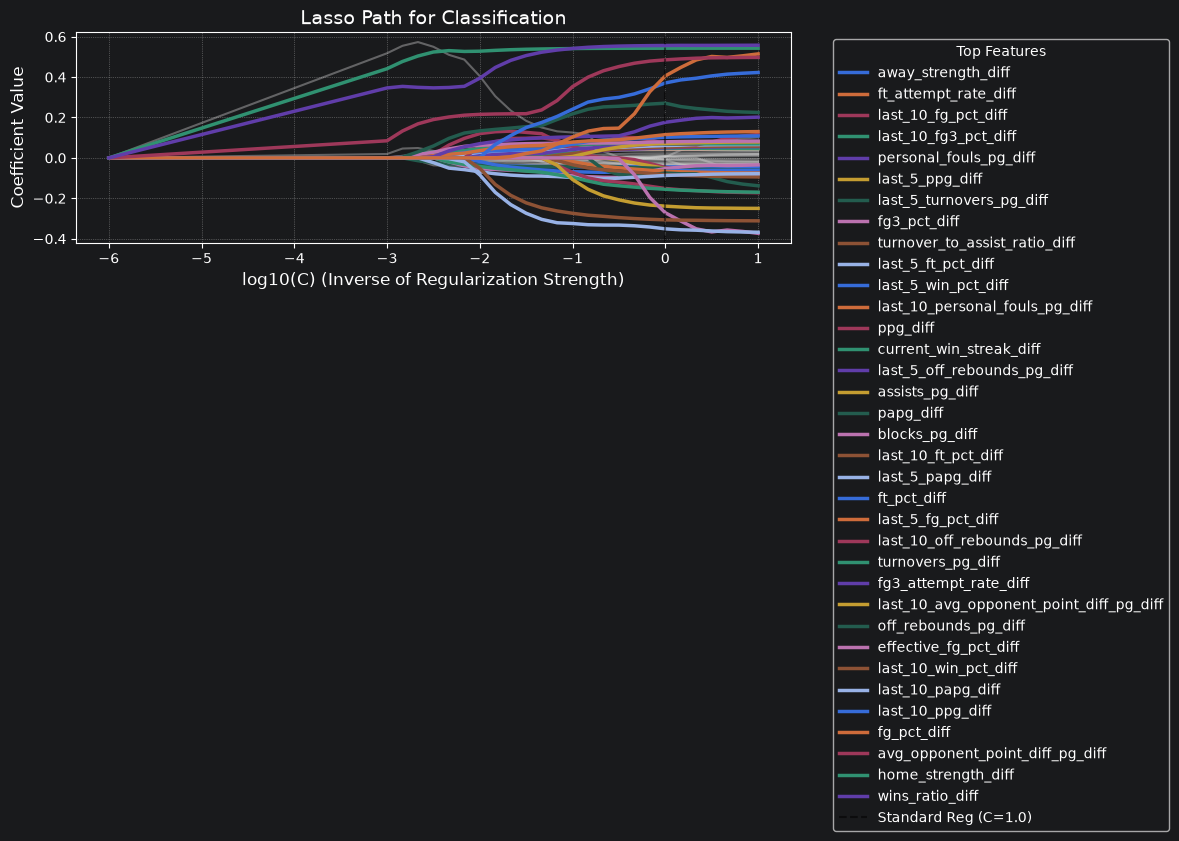

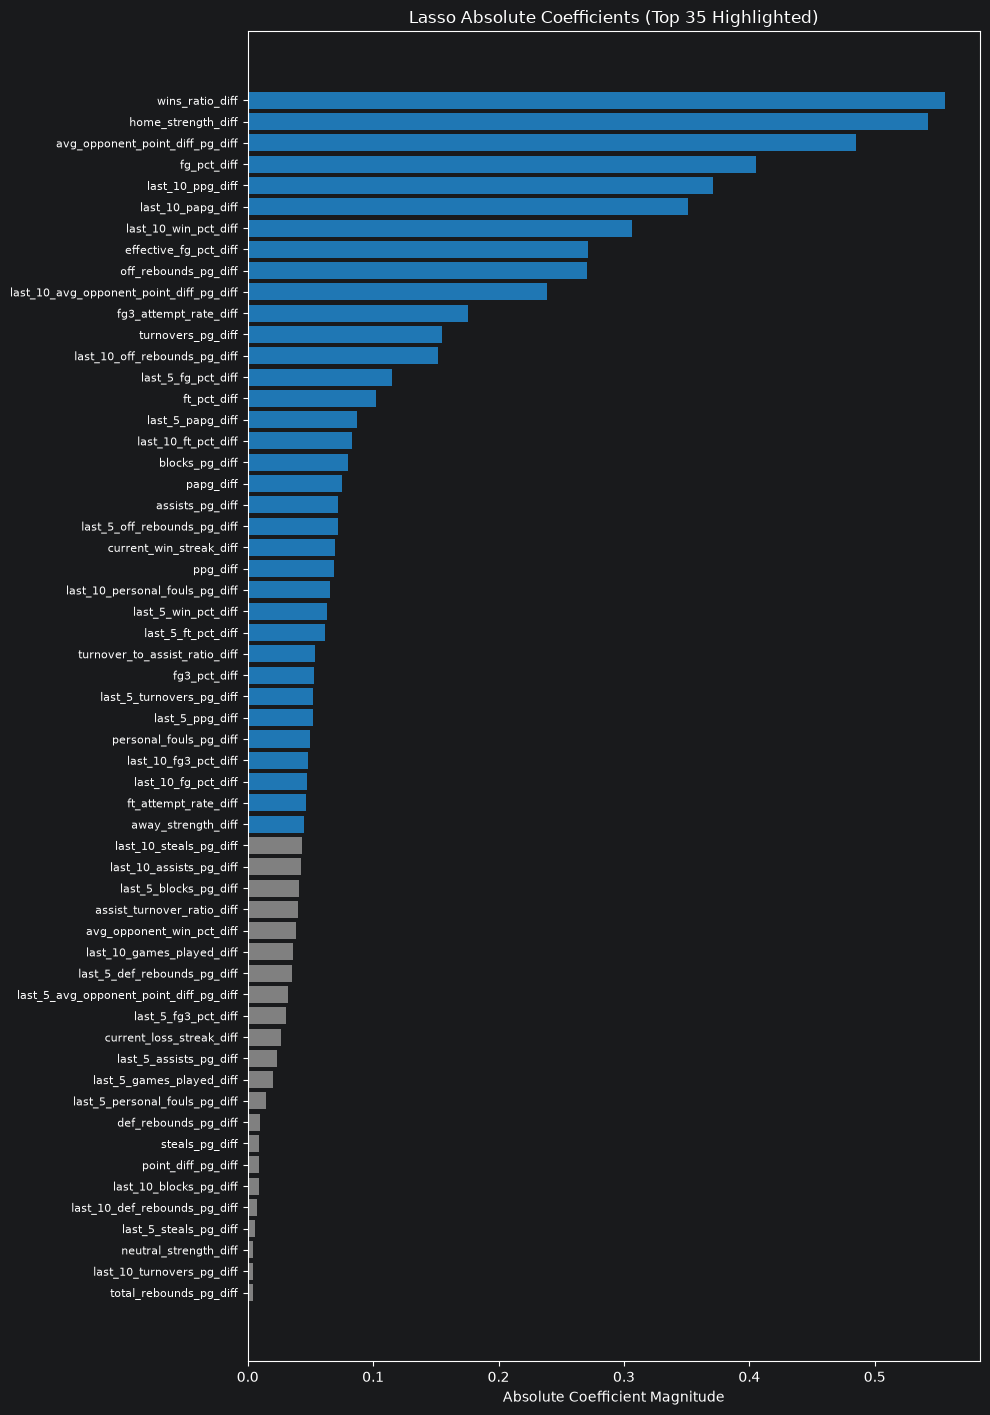

['away_strength_diff',
 'ft_attempt_rate_diff',
 'last_10_fg_pct_diff',
 'last_10_fg3_pct_diff',
 'personal_fouls_pg_diff',
 'last_5_ppg_diff',
 'last_5_turnovers_pg_diff',
 'fg3_pct_diff',
 'turnover_to_assist_ratio_diff',
 'last_5_ft_pct_diff',
 'last_5_win_pct_diff',
 'last_10_personal_fouls_pg_diff',
 'ppg_diff',
 'current_win_streak_diff',
 'last_5_off_rebounds_pg_diff',
 'assists_pg_diff',
 'papg_diff',
 'blocks_pg_diff',
 'last_10_ft_pct_diff',
 'last_5_papg_diff',
 'ft_pct_diff',
 'last_5_fg_pct_diff',
 'last_10_off_rebounds_pg_diff',
 'turnovers_pg_diff',
 'fg3_attempt_rate_diff',
 'last_10_avg_opponent_point_diff_pg_diff',
 'off_rebounds_pg_diff',
 'effective_fg_pct_diff',
 'last_10_win_pct_diff',
 'last_10_papg_diff',
 'last_10_ppg_diff',
 'fg_pct_diff',
 'avg_opponent_point_diff_pg_diff',
 'home_strength_diff',
 'wins_ratio_diff']

In [49]:
import warnings

# Turn of warnings and start with Lasso
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.linear_model")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.linear_model")
selector.run_lasso(target_features=35, print_results=True, plot_results=True)

--- Recursive Feature Elimination (Backward) ---
Selected (35): ['ppg_diff', 'papg_diff', 'fg_pct_diff', 'ft_pct_diff', 'off_rebounds_pg_diff', 'assists_pg_diff', 'turnovers_pg_diff', 'personal_fouls_pg_diff', 'last_5_win_pct_diff', 'last_5_papg_diff', 'last_5_fg_pct_diff', 'last_5_off_rebounds_pg_diff', 'last_5_steals_pg_diff', 'last_5_avg_opponent_point_diff_pg_diff', 'last_10_games_played_diff', 'last_10_win_pct_diff', 'last_10_ppg_diff', 'last_10_papg_diff', 'last_10_def_rebounds_pg_diff', 'last_10_blocks_pg_diff', 'last_10_personal_fouls_pg_diff', 'last_10_avg_opponent_point_diff_pg_diff', 'current_win_streak_diff', 'current_loss_streak_diff', 'point_diff_pg_diff', 'effective_fg_pct_diff', 'total_rebounds_pg_diff', 'fg3_attempt_rate_diff', 'ft_attempt_rate_diff', 'turnover_to_assist_ratio_diff', 'avg_opponent_win_pct_diff', 'avg_opponent_point_diff_pg_diff', 'wins_ratio_diff', 'home_strength_diff', 'away_strength_diff']
Removed  (22): ['fg3_pct_diff', 'def_rebounds_pg_diff', 'stea

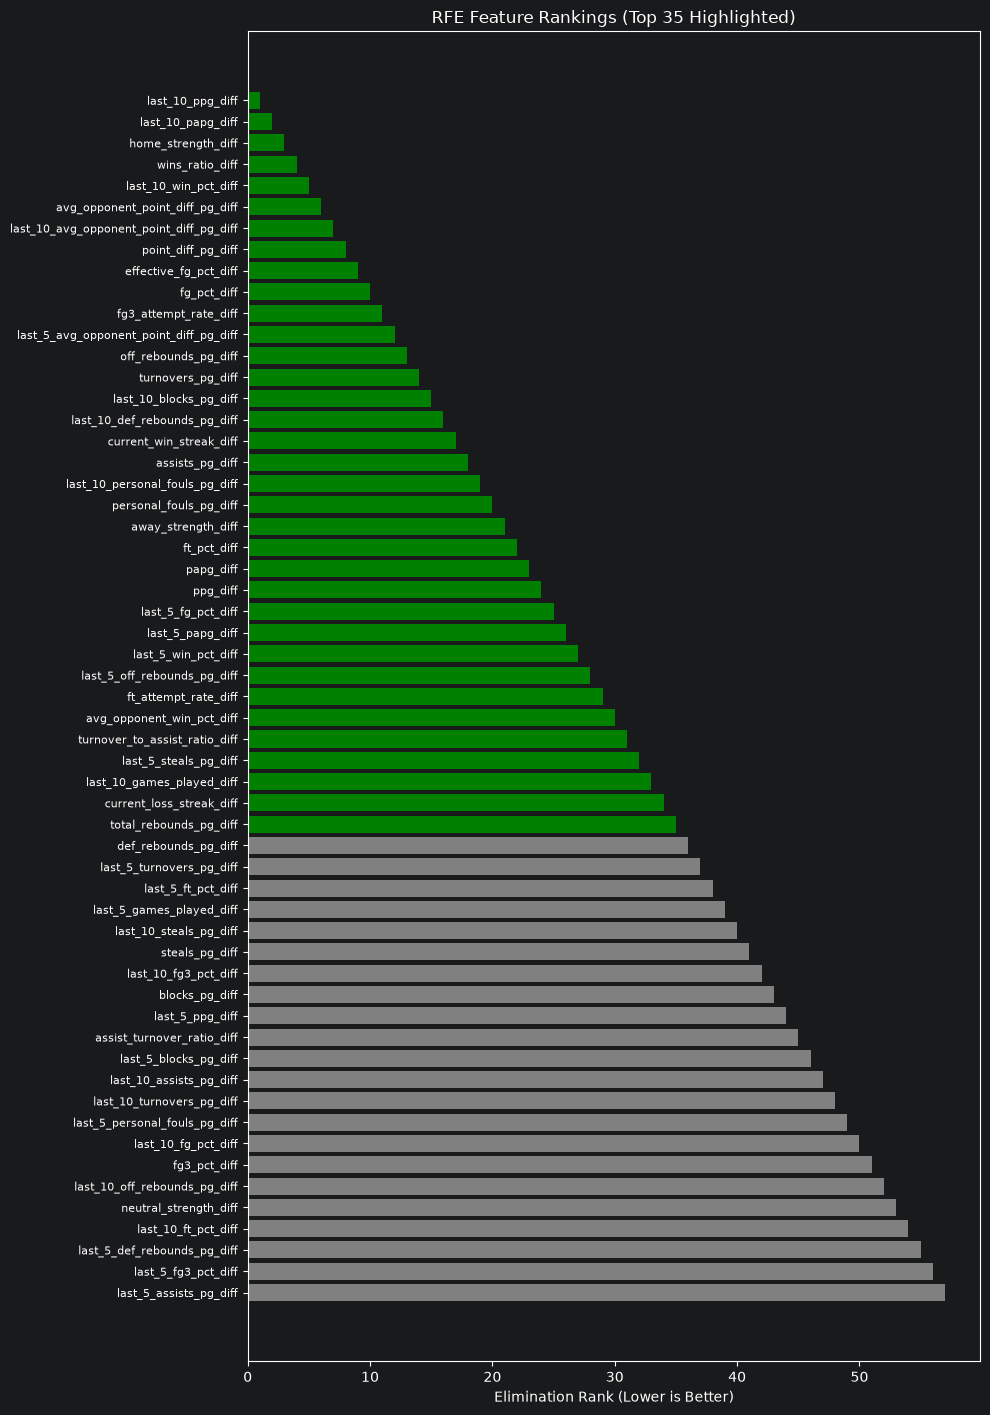

['ppg_diff',
 'papg_diff',
 'fg_pct_diff',
 'ft_pct_diff',
 'off_rebounds_pg_diff',
 'assists_pg_diff',
 'turnovers_pg_diff',
 'personal_fouls_pg_diff',
 'last_5_win_pct_diff',
 'last_5_papg_diff',
 'last_5_fg_pct_diff',
 'last_5_off_rebounds_pg_diff',
 'last_5_steals_pg_diff',
 'last_5_avg_opponent_point_diff_pg_diff',
 'last_10_games_played_diff',
 'last_10_win_pct_diff',
 'last_10_ppg_diff',
 'last_10_papg_diff',
 'last_10_def_rebounds_pg_diff',
 'last_10_blocks_pg_diff',
 'last_10_personal_fouls_pg_diff',
 'last_10_avg_opponent_point_diff_pg_diff',
 'current_win_streak_diff',
 'current_loss_streak_diff',
 'point_diff_pg_diff',
 'effective_fg_pct_diff',
 'total_rebounds_pg_diff',
 'fg3_attempt_rate_diff',
 'ft_attempt_rate_diff',
 'turnover_to_assist_ratio_diff',
 'avg_opponent_win_pct_diff',
 'avg_opponent_point_diff_pg_diff',
 'wins_ratio_diff',
 'home_strength_diff',
 'away_strength_diff']

In [50]:
# Continue to RFE backwards elimination
selector.run_rfe(target_features=35, print_results=True, plot_results=True)

--- Random Forest Importance ---
Selected (35): ['steals_pg_diff', 'turnovers_pg_diff', 'last_10_ft_pct_diff', 'total_rebounds_pg_diff', 'ft_pct_diff', 'off_rebounds_pg_diff', 'last_10_fg3_pct_diff', 'blocks_pg_diff', 'last_5_fg3_pct_diff', 'last_5_ft_pct_diff', 'fg3_pct_diff', 'last_5_fg_pct_diff', 'fg3_attempt_rate_diff', 'last_5_ppg_diff', 'ft_attempt_rate_diff', 'last_10_fg_pct_diff', 'last_5_avg_opponent_point_diff_pg_diff', 'assists_pg_diff', 'last_5_papg_diff', 'effective_fg_pct_diff', 'last_10_avg_opponent_point_diff_pg_diff', 'avg_opponent_win_pct_diff', 'avg_opponent_point_diff_pg_diff', 'assist_turnover_ratio_diff', 'last_10_ppg_diff', 'last_10_papg_diff', 'papg_diff', 'turnover_to_assist_ratio_diff', 'ppg_diff', 'away_strength_diff', 'last_10_win_pct_diff', 'fg_pct_diff', 'wins_ratio_diff', 'home_strength_diff', 'point_diff_pg_diff']
Removed  (22): ['def_rebounds_pg_diff', 'personal_fouls_pg_diff', 'last_5_games_played_diff', 'last_5_win_pct_diff', 'last_5_off_rebounds_pg_d

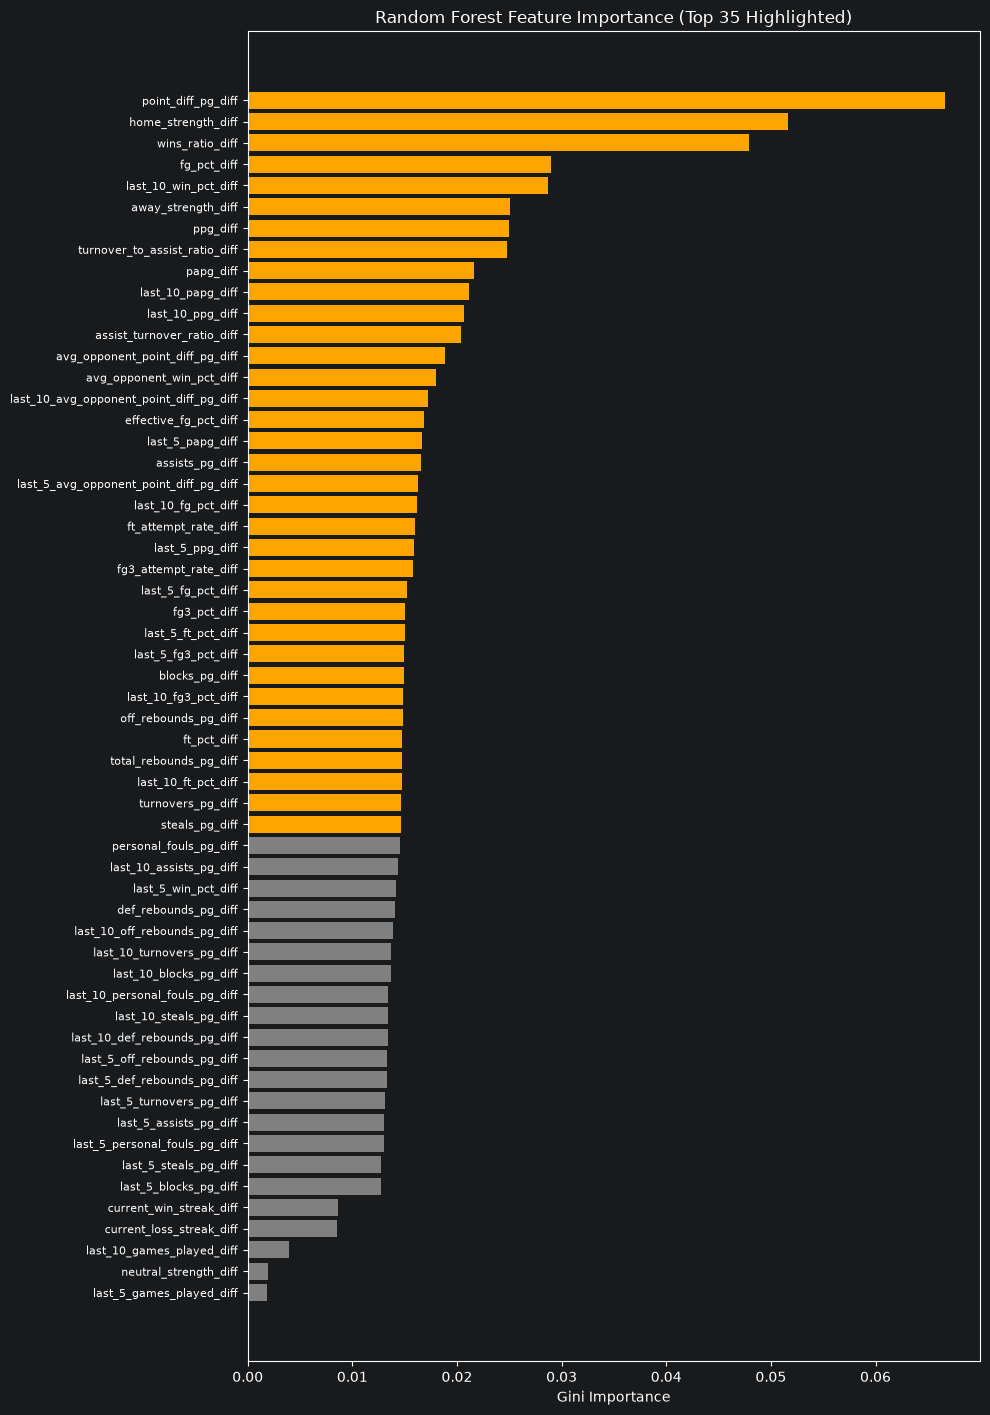

['steals_pg_diff',
 'turnovers_pg_diff',
 'last_10_ft_pct_diff',
 'total_rebounds_pg_diff',
 'ft_pct_diff',
 'off_rebounds_pg_diff',
 'last_10_fg3_pct_diff',
 'blocks_pg_diff',
 'last_5_fg3_pct_diff',
 'last_5_ft_pct_diff',
 'fg3_pct_diff',
 'last_5_fg_pct_diff',
 'fg3_attempt_rate_diff',
 'last_5_ppg_diff',
 'ft_attempt_rate_diff',
 'last_10_fg_pct_diff',
 'last_5_avg_opponent_point_diff_pg_diff',
 'assists_pg_diff',
 'last_5_papg_diff',
 'effective_fg_pct_diff',
 'last_10_avg_opponent_point_diff_pg_diff',
 'avg_opponent_win_pct_diff',
 'avg_opponent_point_diff_pg_diff',
 'assist_turnover_ratio_diff',
 'last_10_ppg_diff',
 'last_10_papg_diff',
 'papg_diff',
 'turnover_to_assist_ratio_diff',
 'ppg_diff',
 'away_strength_diff',
 'last_10_win_pct_diff',
 'fg_pct_diff',
 'wins_ratio_diff',
 'home_strength_diff',
 'point_diff_pg_diff']

In [51]:
# Finish with tree importance for non-linear patterns
selector.run_tree_importance(target_features=35, print_results=True, plot_results=True)

In [54]:
# Save only the features that two methods pointed out as relevant
selector.finalize_selection(vote_threshold=2, print_results=True)

# And update the data frames accordingly
X_train = selector.transform(X_train)
X_test = selector.transform(X_test)

FINAL FEATURE SELECTION VERDICT
Target Threshold: 2 votes required
Total Features Selected: 37

Detailed Voting Breakdown:
[KEEP] assists_pg_diff: 3 vote(s)
[KEEP] avg_opponent_point_diff_pg_diff: 3 vote(s)
[KEEP] away_strength_diff: 3 vote(s)
[KEEP] effective_fg_pct_diff: 3 vote(s)
[KEEP] fg3_attempt_rate_diff: 3 vote(s)
[KEEP] fg_pct_diff: 3 vote(s)
[KEEP] ft_attempt_rate_diff: 3 vote(s)
[KEEP] ft_pct_diff: 3 vote(s)
[KEEP] home_strength_diff: 3 vote(s)
[KEEP] last_10_avg_opponent_point_diff_pg_diff: 3 vote(s)
[KEEP] last_10_papg_diff: 3 vote(s)
[KEEP] last_10_ppg_diff: 3 vote(s)
[KEEP] last_10_win_pct_diff: 3 vote(s)
[KEEP] last_5_fg_pct_diff: 3 vote(s)
[KEEP] last_5_papg_diff: 3 vote(s)
[KEEP] off_rebounds_pg_diff: 3 vote(s)
[KEEP] papg_diff: 3 vote(s)
[KEEP] ppg_diff: 3 vote(s)
[KEEP] turnover_to_assist_ratio_diff: 3 vote(s)
[KEEP] turnovers_pg_diff: 3 vote(s)
[KEEP] wins_ratio_diff: 3 vote(s)
[KEEP] avg_opponent_win_pct_diff: 2 vote(s)
[KEEP] blocks_pg_diff: 2 vote(s)
[KEEP] curr

In [55]:
from pathlib import Path

# Project root is two levels above src/notebook
data_dir = Path("../../data")
data_dir.mkdir(parents=True, exist_ok=True)

X_train.to_csv(data_dir / "X_train.csv", index=False)
X_test.to_csv(data_dir / "X_test.csv", index=False)
y_train.to_csv(data_dir / "y_train.csv", index=False)
y_test.to_csv(data_dir / "y_test.csv", index=False)

print(f"Saved dataframes to {data_dir.resolve()}")

Saved dataframes to C:\Users\Itay\DataspellProjects\march-not-so-madness\data
